# Phase 4 : Modélisation et Clustering (Volet 2)

## Introduction
Suite à notre Analyse en Composantes Principales (ACP) qui nous a permis de comprendre les relations entre nos variables (notamment le lien fort entre l'historique de bananes, la position géographique et le taux de chlordécone), nous passons à la phase de classification.

L'objectif de cette section est de répondre aux exigences d'aide à la décision du projet : **identifier des profils de territoires et des zones à risque**. 

---

### 1. Préparation des données et Méthode du Coude (Elbow Method)
Nous allons utiliser l'algorithme de classification non supervisée **K-Means** (Centres mobiles). La première étape de cet algorithme consiste à déterminer le nombre optimal de clusters ($K$). 

Pour ce faire, nous appliquons la méthode du coude : nous testons plusieurs valeurs de $K$ (de 1 à 10) et calculons l'inertie intra-classe (la dispersion à l'intérieur des groupes). Le point d'inflexion (la cassure ou "coude" de la courbe) nous indiquera le nombre idéal de profils à retenir.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
# 1. Chargement des données propres
df = pd.read_csv('chlordecone_clean.csv')

In [4]:
# 2. Sélection des variables quantitatives (identique à l'ACP)
colonnes_num = df.select_dtypes(include=['float64', 'int64']).columns
colonnes_a_garder = [col for col in colonnes_num if col not in ['ID', 'ANNEE']]
df_num = df[colonnes_a_garder]

In [5]:
# 3. Standardisation des données (Indispensable pour le calcul des distances K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)

In [6]:
# 4. Calcul de l'inertie pour K allant de 1 à 10
inerties = []
K_range = range(1, 11)

for k in K_range:
    # n_init=10 est une bonne pratique pour éviter de tomber dans un minimum local
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inerties.append(kmeans.inertia_)

print("Inerties pour K de 1 à 10 :", inerties)

Inerties pour K de 1 à 10 : [331419.00000000047, 278667.1699570853, 245677.32571869678, 215647.43443699225, 196230.86330120728, 180115.84513136526, 166350.49335015338, 157156.77356865304, 148303.21446667984, 141127.01994159416]


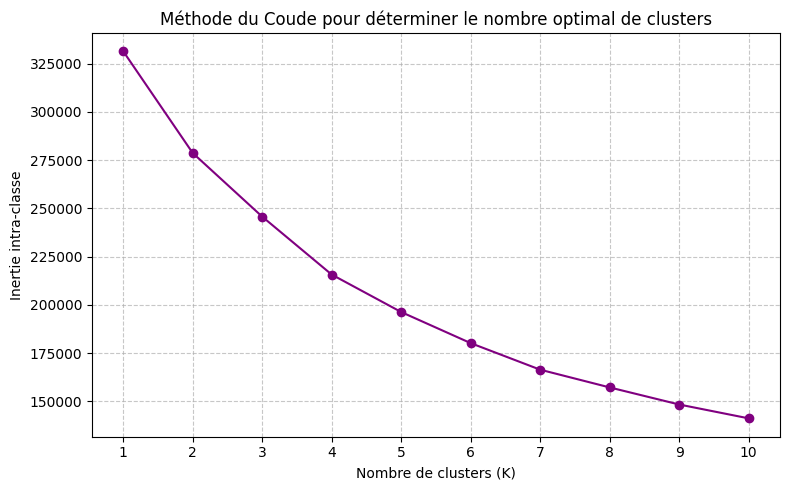

In [7]:
# 5. Création du graphique du Coude
plt.figure(figsize=(8, 5))
plt.plot(K_range, inerties, marker='o', color='purple', linestyle='-')
plt.title('Méthode du Coude pour déterminer le nombre optimal de clusters')
plt.xlabel('Nombre de clusters (K)')
plt.ylabel('Inertie intra-classe')
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 2. Choix du nombre de clusters (K=4)
L'analyse des valeurs d'inertie et du graphique de la méthode du coude montre une cassure de la courbe autour de **K=4**. Au-delà de ce point, la diminution de l'inertie intra-classe devient beaucoup moins significative. 

Nous choisissons donc de segmenter nos parcelles en **4 clusters distincts** (4 profils de territoires).

---

### 3. Application de l'algorithme K-Means et Profilage
Nous allons maintenant entraîner notre modèle K-Means définitif avec 4 groupes. Une fois l'algorithme exécuté, chaque parcelle se verra attribuer un numéro de cluster (de 0 à 3). 

Afin de pouvoir interpréter ces profils et faire de l'aide à la décision (identifier les zones à risque), nous allons calculer la moyenne des variables clés (Taux de Chlordécone, Historique Banane, Altitude, Coordonnées) pour chaque cluster.

In [8]:
#1. Initialisation et entrainement du modèle k-means final avec k = 4

kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10) 
clusters = kmeans_final.fit_predict(X_scaled)

print("Centres des clusters (en données standardisées) :\n", kmeans_final.cluster_centers_)
print("Labels des clusters pour chaque échantillon :\n", clusters)

Centres des clusters (en données standardisées) :
 [[-3.28664281e-01 -6.80100035e-02 -2.11584223e-01 -8.65993607e-02
  -3.64838591e-01 -3.63339622e-01  1.14302577e-01  5.14008693e-02
  -3.65805086e-01  6.89246041e-01 -6.95017278e-01]
 [-1.13036456e-03 -6.78265805e-02 -6.52738632e-02  1.88084315e-01
   1.45348208e+00  1.47416237e+00 -4.62726145e-01  2.42816114e-03
   1.48716499e+00 -2.47861492e-01  1.58240536e-01]
 [ 4.87919303e-01 -6.75771330e-02  3.44869387e-01  1.28596987e-02
  -3.38593831e-01 -3.54369646e-01  1.14531903e-01 -8.03909448e-02
  -3.58202586e-01 -8.76773466e-01  9.37141684e-01]
 [-1.62638208e-01  1.47419814e+01  4.68816237e-01  1.13617212e-01
   9.13252442e-02  1.69409384e-01 -3.12496688e-01  2.18012773e-01
   1.43820298e-01  6.44472949e-01 -4.93602265e-01]]
Labels des clusters pour chaque échantillon :
 [1 1 1 ... 2 0 0]


In [9]:
#2 ajout de la colonne 'Cluster' a nootre jeu de donnée proprée
df['cluster'] = clusters
df_num['cluster'] = clusters

print("Distribution des échantillons par cluster :\n", df['cluster'].value_counts())
print("Moyennes des variables par cluster :\n", df_num.groupby('cluster').mean())

Distribution des échantillons par cluster :
 cluster
0    14391
2     9751
1     5849
3      138
Name: count, dtype: int64
Moyennes des variables par cluster :
          Taux_Chlordecone  Taux_5b_hydro  histoBanane_Histo_ban  mnt_tpi_mean  \
cluster                                                                         
0                0.159039       0.006066               0.503787     -0.004674   
1                0.678779       0.018479               0.644042      0.707253   
2                1.448896       0.035250               1.033638      0.253577   
3                0.421568     999.000000               1.152174      0.513469   

         mnt_tri_mean  mnt_rugosite_mean  mnt_ombrage_mean  \
cluster                                                      
0            3.283193          10.355526        178.123297   
1            8.502450          26.246752        161.992055   
2            3.357316          10.429358        178.129585   
3            4.588182          14.949099  

C:\Users\mopit\AppData\Local\Temp\ipykernel_125912\1267855861.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_num['cluster'] = clusters


In [10]:
#3 comptage du nombre de parcelles par cluster
print("---- Nombre de parcelles par cluster ----")
print(df['cluster'].value_counts().sort_index())

---- Nombre de parcelles par cluster ----
cluster
0    14391
1     5849
2     9751
3      138
Name: count, dtype: int64


In [11]:
#4. Calcul des moyennes par cluster pour interpreter les profils 
variables_cles = ['Taux_Chlordecone', 'histoBanane_Histo_ban','X', 'Y','mnt_pente_mean']
profils_clusters = df.groupby('cluster')[variables_cles].mean()


print("\n----Profils moyens de chaque clusters------- :\n", profils_clusters)
print(profils_clusters.round(3))


----Profils moyens de chaque clusters------- :
          Taux_Chlordecone  histoBanane_Histo_ban              X             Y  \
cluster                                                                         
0                0.159039               0.503787  719828.490465  1.615897e+06   
1                0.678779               0.644042  710547.387651  1.625939e+06   
2                1.448896               1.033638  704350.419824  1.635082e+06   
3                0.421568               1.152174  719385.392781  1.618263e+06   

         mnt_pente_mean  
cluster                  
0             15.451342  
1             40.304943  
2             15.547142  
3             22.265611  
         Taux_Chlordecone  histoBanane_Histo_ban           X            Y  \
cluster                                                                     
0                   0.159                  0.504  719828.490  1615896.574   
1                   0.679                  0.644  710547.388  1625938.633   


In [12]:
# 1. Calcul du pourcentage de parcelles par cluster
pourcentages_clusters = (df['cluster'].value_counts(normalize=True).sort_index() * 100).round(2)

# 2. Affichage propre des résultats
print("--- Répartition des parcelles par profil ---")
for cluster, pct in pourcentages_clusters.items():
    print(f"Cluster {cluster} : {pct} %")

--- Répartition des parcelles par profil ---
Cluster 0 : 47.76 %
Cluster 1 : 19.41 %
Cluster 2 : 32.36 %
Cluster 3 : 0.46 %


### 4. Profilage des Territoires et Aide à la Décision
L'analyse des moyennes par cluster nous permet de dresser le "portrait-robot" de nos 4 profils de territoires, confirmant ainsi nos découvertes de l'ACP :

* **Cluster 0 (Zone saine, ~48% des parcelles)** : Territoire présentant le taux de chlordécone le plus faible (0.15) et le plus faible historique de culture de banane. 
* **Cluster 1 (Zone pentue, ~19% des parcelles)** : Profil atypique caractérisé par une topographie très accidentée (pente moyenne de 40.3). La contamination y est modérée (0.67).
* **Cluster 2 (Zone critique, ~32% des parcelles)** : C'est la **zone à haut risque**. Elle concentre les taux de chlordécone les plus élevés (1.45 en moyenne) et une forte activité historique bananière. Géographiquement, ce cluster correspond au Nord-Ouest de la zone d'étude.
* **Cluster 3 (Anomalies techniques, < 1%)** : Micro-cluster ayant isolé les parcelles présentant des valeurs aberrantes résiduelles (notamment sur le `Taux_5b_hydro` à 999).

---

### 5. Visualisation Spatiale des Zones à Risque (Cartographie)
Pour fournir un véritable outil d'aide à la décision publique, il est indispensable de visualiser ces clusters sur une carte. 
Grâce aux coordonnées géographiques `X` (Longitude) et `Y` (Latitude) présentes dans notre jeu de données, nous pouvons recréer la carte du territoire et y projeter nos parcelles, colorées en fonction de leur niveau de risque (leur cluster).

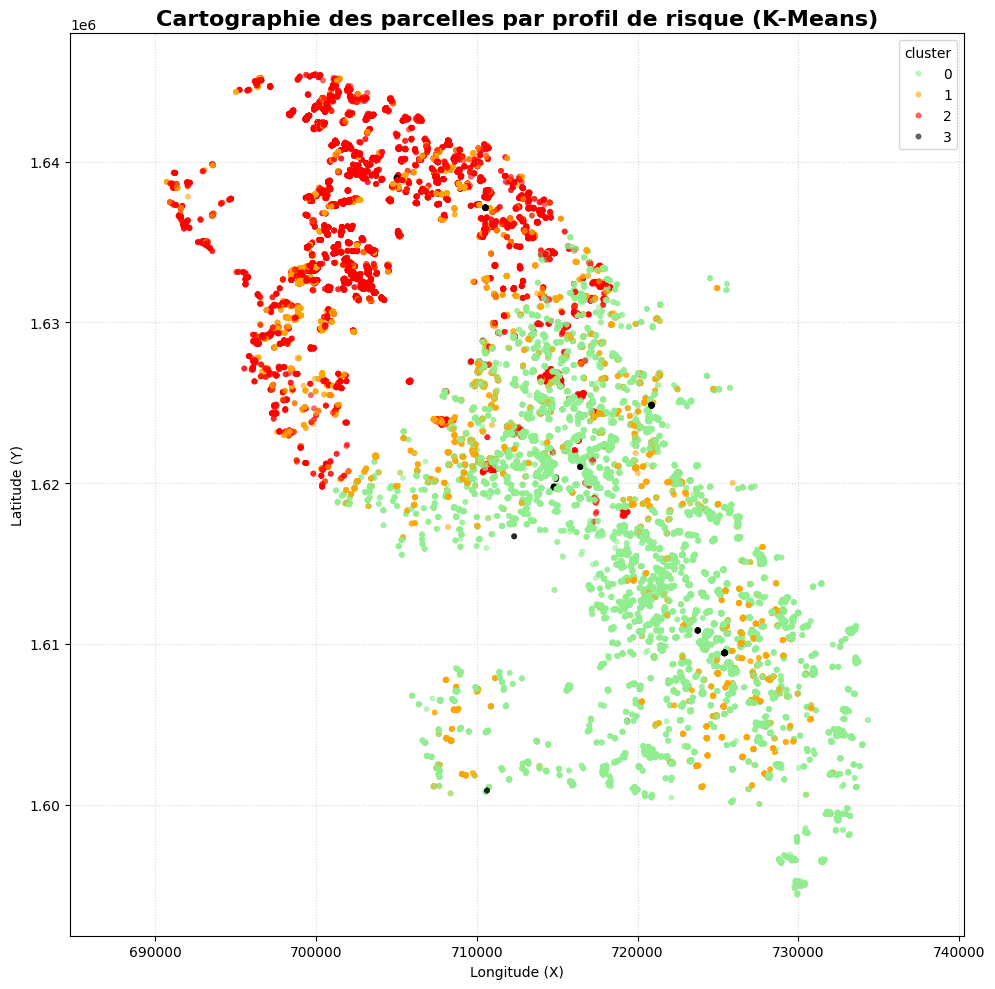

In [13]:
plt.figure(figsize=(10, 10))

couleurs_clusters = {
    0: 'lightgreen', # Cluster 0 : Zone saine 
    1: 'orange',     # Cluster 1 : Zone pentue
    2: 'red',        # Cluster 2 : Zone critique (haut risque de contamination)
    3: 'black'       # Cluster 3 : Anomalie
}

# Création de la carte spatiale (Y en ordonnée, X en abscisse)
sns.scatterplot(
    data=df, 
    x='X', y='Y', 
    hue='cluster', 
    palette=couleurs_clusters,
    s=15,          # Taille des points
    alpha=0.6,     # Transparence pour voir la densité
    edgecolor=None
)

# Esthétique de la carte
plt.title('Cartographie des parcelles par profil de risque (K-Means)', fontsize=16, fontweight='bold')
plt.xlabel('Longitude (X)')
plt.ylabel('Latitude (Y)')
plt.grid(True, linestyle=':', alpha=0.5)

# Forcer les axes à avoir la même échelle pour ne pas déformer la carte
plt.axis('equal') 

plt.tight_layout()
plt.show()

### 5. Visualisation Spatiale Détaillée des Zones à Risque
Pour fournir un outil d'aide à la décision directement exploitable, nous enrichissons notre cartographie spatiale. En plus de projeter nos parcelles colorées par niveau de risque (Cluster), nous calculons le barycentre géospatial de chaque localité (`COMMU_LAB`) afin d'afficher le nom des communes directement sur la carte. 

Cela permet d'identifier précisément et visuellement quelles sont les municipalités les plus impactées par la "Zone Critique" (Cluster 2 - Rouge) et celles qui se trouvent en "Zone Saine" (Cluster 0 - Vert).

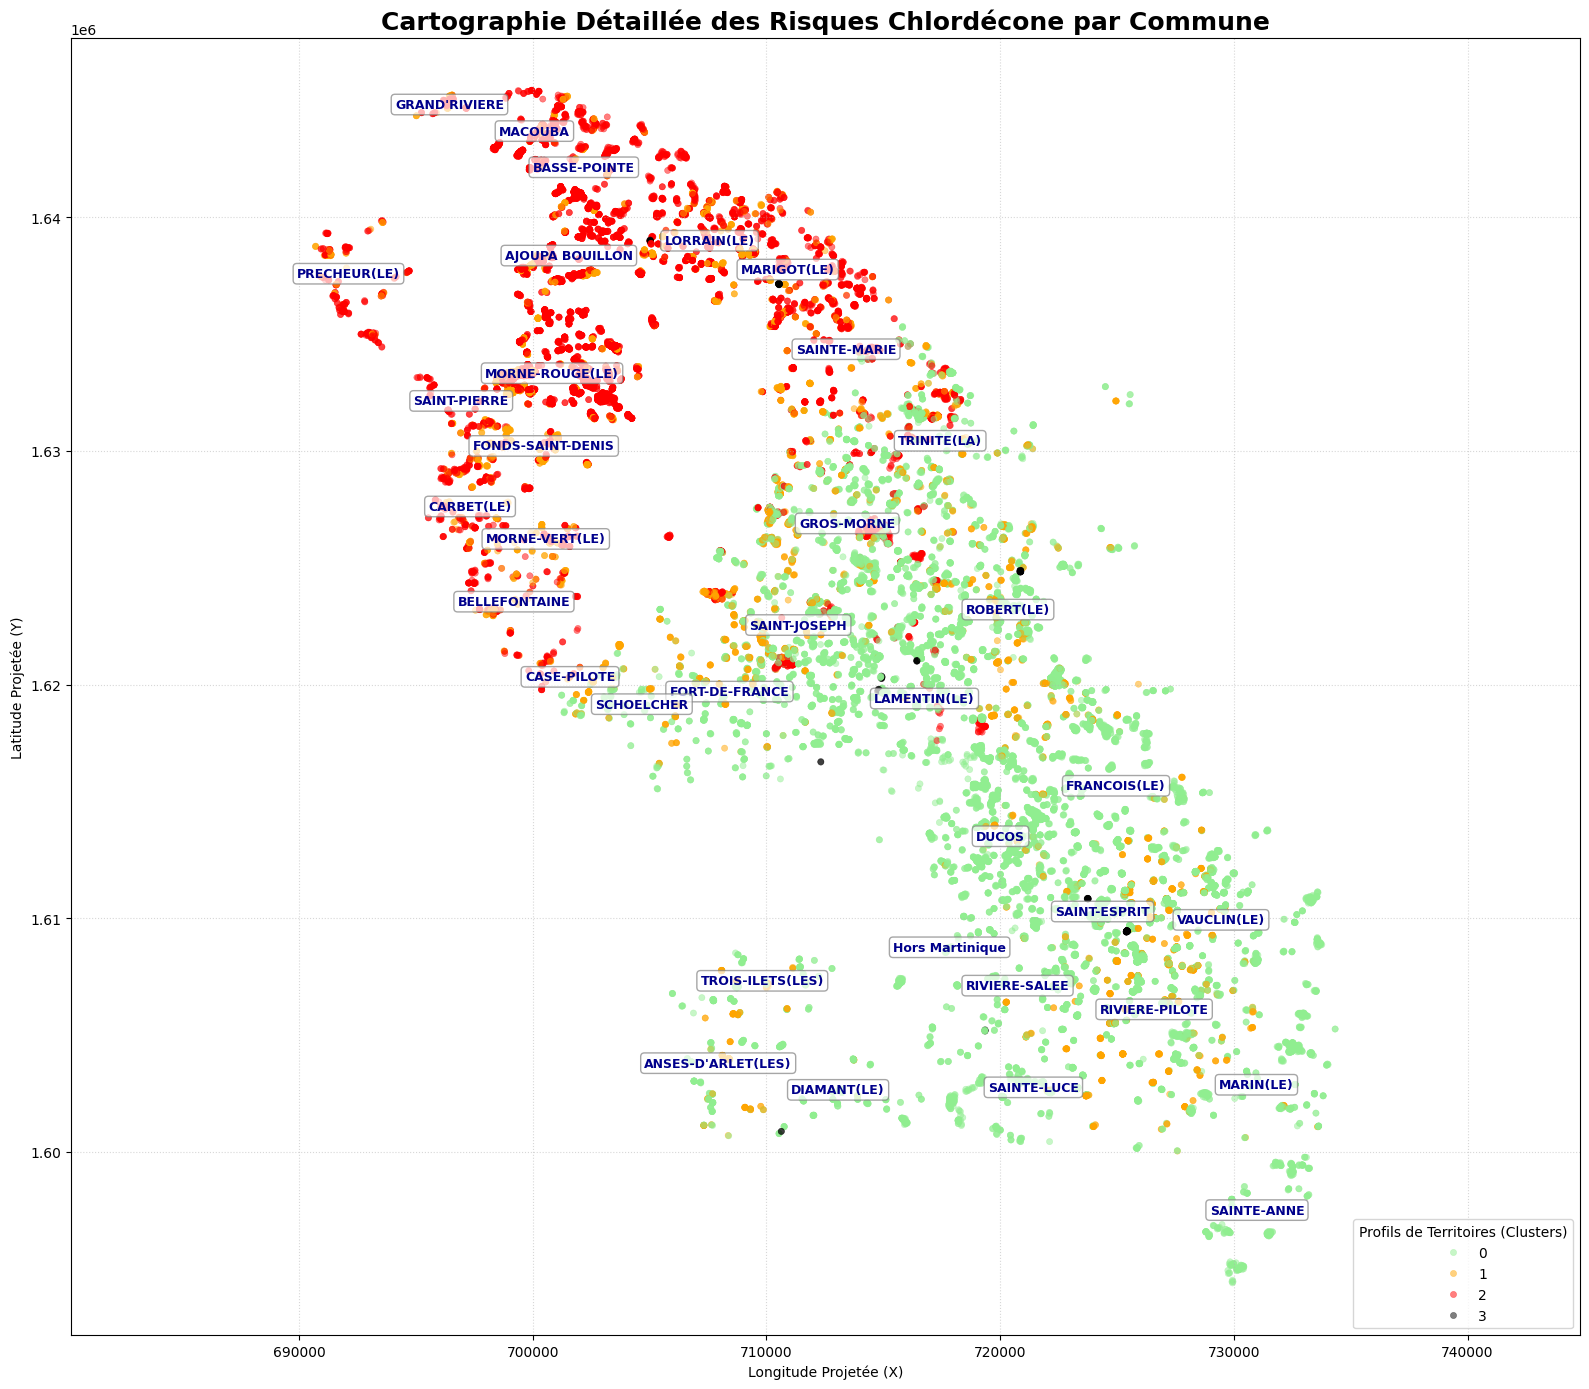

In [14]:
plt.figure(figsize=(16, 14)) # On agrandit un peu la figure pour que le texte respire

# 1. Définition des couleurs (identique à avant)
couleurs_clusters = {
    0: 'lightgreen', # Zone saine
    1: 'orange',     # Zone pentue
    2: 'red',        # Zone critique (Haut risque)
    3: 'black'       # Anomalies
}

# 2. Création de la carte des parcelles
sns.scatterplot(
    data=df, x='X', y='Y', hue='cluster', 
    palette=couleurs_clusters, s=20, alpha=0.5, edgecolor=None, legend=True
)

# 3. Calcul du centre de chaque commune et ajout du texte
centres_communes = df.groupby('COMMU_LAB')[['X', 'Y']].mean()

for commune, row in centres_communes.iterrows():
    plt.text(
        row['X'], row['Y'], commune, 
        fontsize=9, weight='bold', color='darkblue',
        ha='center', va='center',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray', boxstyle='round,pad=0.3')
    )

# 4. Esthétique de la carte
plt.title('Cartographie Détaillée des Risques Chlordécone par Commune', fontsize=18, fontweight='bold')
plt.xlabel('Longitude Projetée (X)')
plt.ylabel('Latitude Projetée (Y)')
plt.grid(True, linestyle=':', alpha=0.5)

# Forcer les axes à avoir la même échelle pour respecter la vraie géographie
plt.axis('equal') 

# Ajustement de la légende
plt.legend(title='Profils de Territoires (Clusters)', loc='lower right')

plt.tight_layout()
plt.show()

### 6. Conclusion de l'Analyse Spatiale et Recommandations publiques
La projection de nos clusters sur la carte détaillée confirme l'existence d'une fracture géographique majeure quant à la contamination à la chlordécone. 

L'analyse visuelle de la carte met en évidence que la **Zone Critique (Cluster 2 - Rouge)** se concentre massivement dans le Nord et le Nord-Ouest du territoire. Des communes comme **Saint-Pierre** ou **Grand'Rivière** se retrouvent au cœur de cette zone à très haut risque. Cela s'explique par la forte concentration historique de bananeraies dans ce secteur géographique.

**Recommandations pour l'aide à la décision :**
1. **Priorisation sanitaire** : Concentrer les campagnes de dépistage (sols et populations) en priorité sur les communes du Nord/Nord-Ouest (Cluster 2).
2. **Prévention agricole** : Accompagner les agriculteurs de ces secteurs vers des cultures non sensibles à la chlordécone (ex: vergers) ou des méthodes de décontamination.
3. **Surveillance des anomalies** : Mener un audit ciblé sur les quelques parcelles du Cluster 3 pour identifier la source des erreurs de mesure (taux aberrants).

In [15]:
# Sauvegarde des données enrichies avec les profils de territoires
df.to_csv('chlordecone_clustered.csv', index=False)
print("Fichier sauvegardé avec succès pour le Dashboard !")

Fichier sauvegardé avec succès pour le Dashboard !
